In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt

import utilities as utils
import care

# Evaluating operators trained on measured data

In [2]:
# --!--------------------------------------------------------------------------
# --! load trained models

model = torch.load('models/kind_meas.pt', weights_only=False)
model.eval()

detuning(
  (operator_sta): operator_sta(
    (enc): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=40, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=320, bias=True)
          (1): Identity()
        )
      )
    )
    (model): Linear(in_features=6, out_features=6, bias=False)
    (dec_mean): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=6, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=40, bias=True)
          (1): Identity()
        )
      )
    )
    (dec_var): fcnn(
      (net)

### Analysis of global operator eigenvalues

The trained operator successfully identifies the single mode present in the data, hence one pair of complex eigenvalues. The fact that this pair resides on the unit circle reflects the absense of decay in the real-world data. The other two eigenvalues are real.

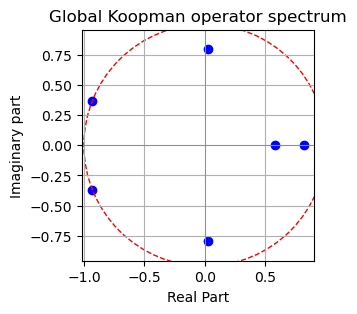

In [3]:
# --!--------------------------------------------------------------------------
# --! visualize global operator eigenvalues

with torch.no_grad():
    eigvals, eigvecs = torch.linalg.eig(model.operator_sta.model.weight)
    utils.disp_spectrum(eigvals)

The amplitude plots below demonstrate that the real eigenvalues do not play much role when the model responds to input sinusoidal data---the majority of the work is carried out by the complex pair.

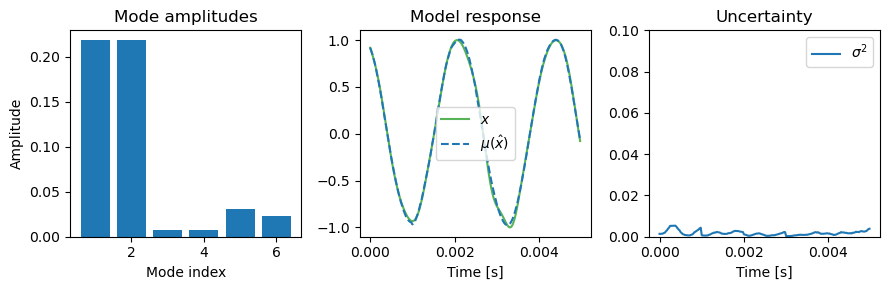

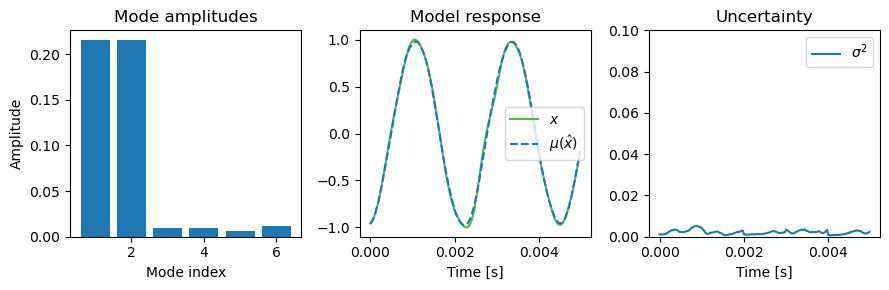

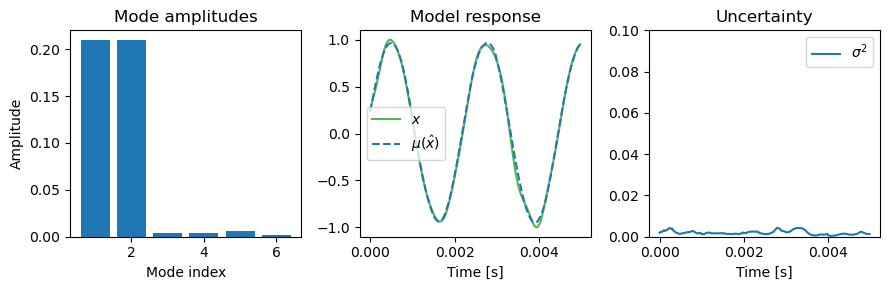

In [4]:
# --!--------------------------------------------------------------------------
# --! analyze the amplitude of global operator eigenvalues

dataset_dir         = 'data/train_meas_g'
timeseries_nsample  = 200

with torch.no_grad():
    for timeseries_pos in range(3):
        utils.disp_spectrum_amps(model, dataset_dir, timeseries_nsample, timeseries_pos)

### Global model evaluation

The global operator, trained solely on stationary cavity detuning data, fails to capture the transitional behavior present in the real-world signal, such as rising or falling oscillation envelopes.

tensor(0.0062)


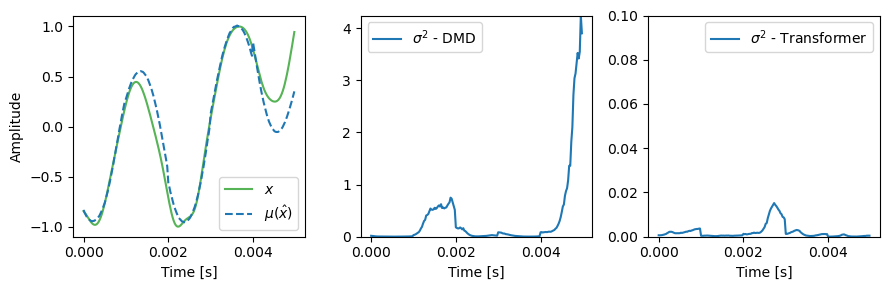

tensor(0.0115)


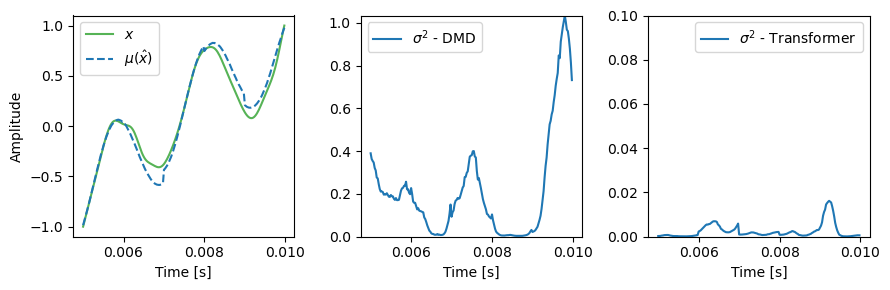

tensor(0.6828)


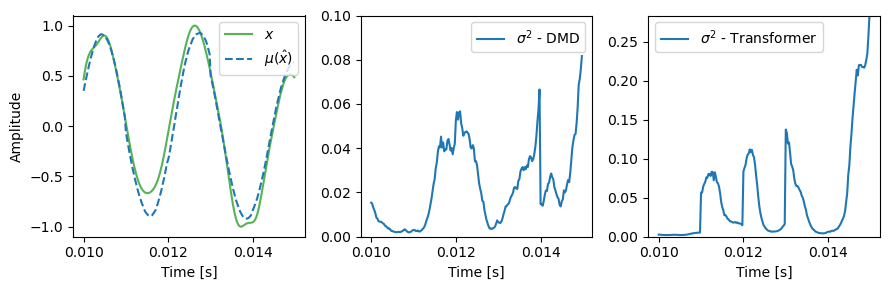

tensor(0.0121)


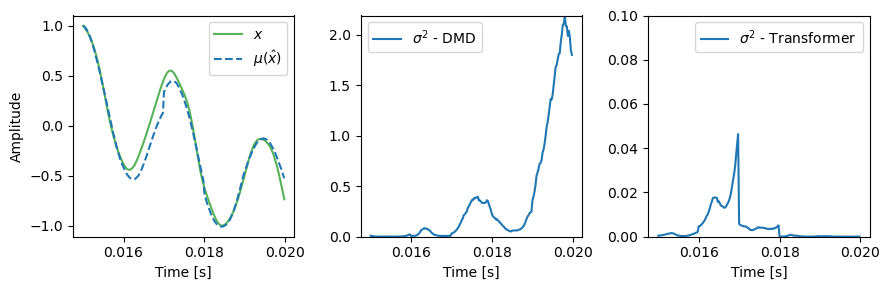

tensor(0.0794)


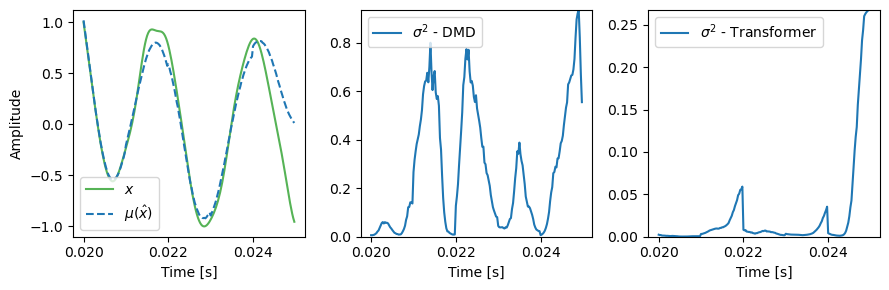

tensor(0.0158)


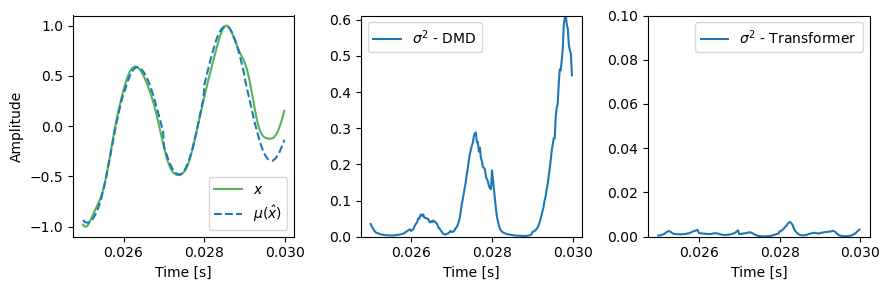

tensor(0.1057)


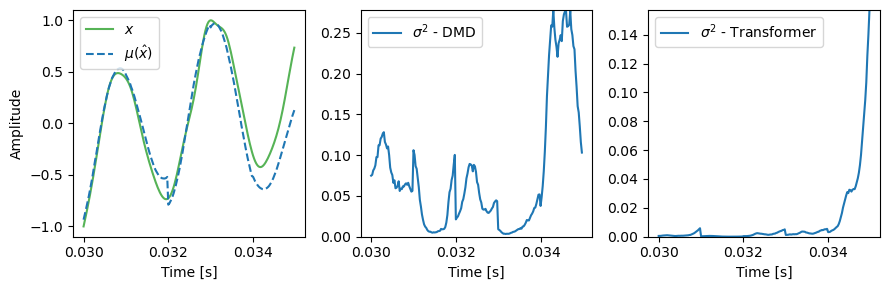

tensor(0.6939)


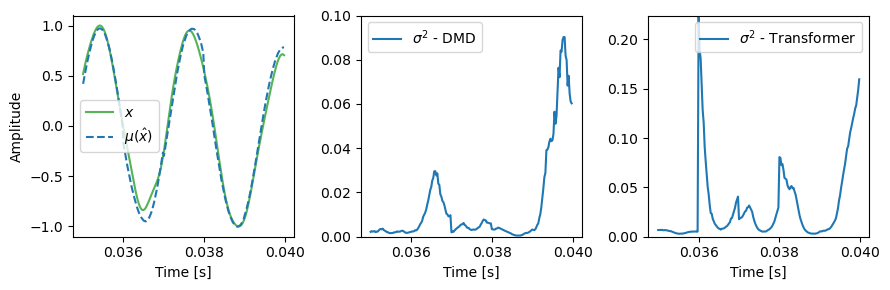

tensor(0.1473)


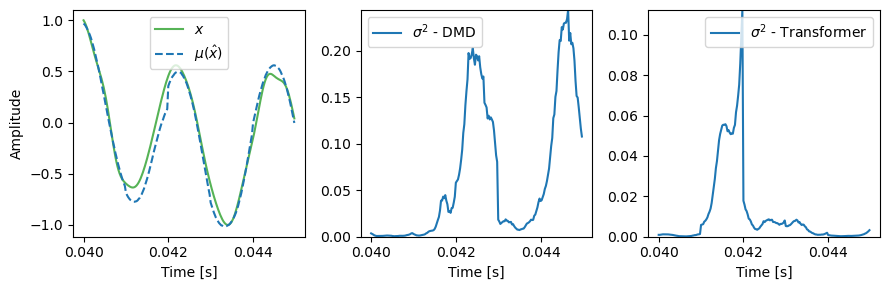

tensor(0.7341)


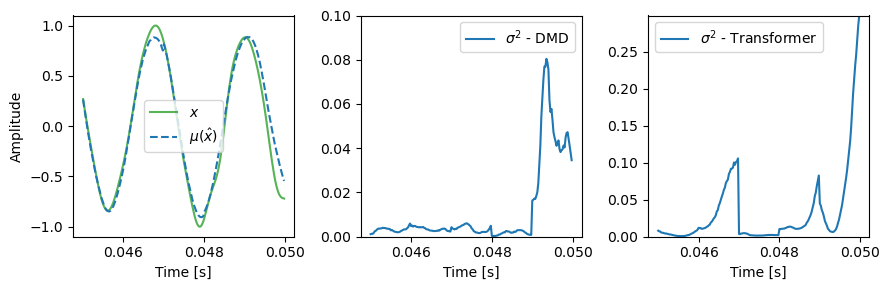

In [6]:
# --!--------------------------------------------------------------------------
# --! evaluate a global model

eval_dataset_dir        = 'data/eval_meas'
eval_timeseries_nsample = 200

with torch.no_grad():
    alpha = [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
    utils.eval_model(model, alpha, eval_dataset_dir, eval_timeseries_nsample, datasaved=False)